In [1]:
from astropy.io import fits # for fits file
import matplotlib.pyplot as plt # for data visualisation
import numpy as np # for math and array
import os # to manipulate folder/directory and files
from tqdm import tqdm
%cd captures/ 

/Users/lalyboyer/Desktop/software/captures


In [2]:
def asymmetric_gaussian(x, A, x0, sigma0, a, y0):
    # sigma varie en fonction de x pour créer la queue d'un côté
    sigma = 2 * sigma0 / (1 + np.exp(a * (x - x0)))
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2)) + y0

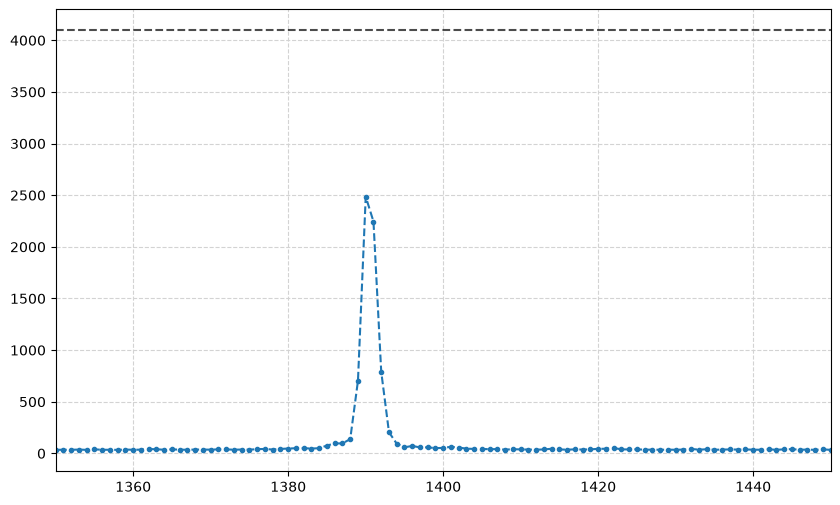

In [3]:
with fits.open("laser_2/science/capture_200_20260625_172418.fits") as hdul:
    data = hdul[0].data

x = np.arange(1936)
y = data[350,:] #-  33.56 
# plt.imshow(data)

fig, ax = plt.subplots(figsize=(10,6))
ax.grid(ls='--',c='lightgrey')
# ax.set_yscale('log')
# ax.plot(data[200,:],ls='--',marker='.')
# ax.plot(data[400,:],ls='--',marker='.')
ax.plot(x, y,ls='--',marker='.')
# ax.plot(data[800,:],ls='--',marker='.')
# ax.plot(data[1000,:],ls='--',marker='.')
# ax.plot(data[1200,:],ls='--',marker='.')
# ax.set_ylim(20,200)
# ax.set_ylim(20,2500)
# ax.set_yscale('log')
ax.set_xlim(1350,1450)
# ax.set_xlim(1250,1500)
ax.axhline(y=4096,ls='--',color='black',alpha=0.7)

In [4]:
# On prend les points où x est inférieur à 1370 OU supérieur à 1420
zone_fond = (x < 1370) | (x > 1420)

# Le fond continu moyen est simplement la moyenne de ces points
y0_estime = np.mean(y[zone_fond])
print(f"Valeur estimée du fond continu : {y0_estime:.2f} coups")

Valeur estimée du fond continu : 33.19 coups


In [5]:
def asymmetric_pseudo_voigt(x, A, x0, sigma, gamma_L, gamma_R, y0):
    """
    Un profil hybride (Pseudo-Voigt) qui permet d'avoir des ailes lorentziennes
    des deux côtés, mais avec des largeurs différentes à gauche et à droite.
    """
    # On sépare le côté gauche du côté droit
    gamma = np.where(x < x0, gamma_L, gamma_R)
    
    # Profil de Lorentz (pour les queues qui s'étalent)
    lorentz = (gamma**2) / ((x - x0)**2 + gamma**2)
    
    # Profil Gaussien (pour le cœur du pic)
    gauss = np.exp(-(x - x0)**2 / (2 * sigma**2))
    
    # On mélange les deux (50% Gauss, 50% Lorentz par exemple, ou laisser un paramètre libre)
    return A * (0.5 * gauss + 0.5 * lorentz) + y0

/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_50054/65441816.py:3: RuntimeWarning: overflow encountered in exp
  sigma = 2 * sigma0 / (1 + np.exp(a * (x - x0)))
/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_50054/65441816.py:4: RuntimeWarning: divide by zero encountered in divide
  return A * np.exp(-(x - x0)**2 / (2 * sigma**2)) + y0
/var/folders/zp/hm1zjt9x4814zq66pqxyw35w0000gn/T/ipykernel_50054/65441816.py:4: RuntimeWarning: overflow encountered in divide
  return A * np.exp(-(x - x0)**2 / (2 * sigma**2)) + y0


--- Résultats du Fit ---
Amplitude réelle estimée : 2696.4
Centre de la raie (x0)   : 1390.39
Fond continu (y0)        : 33.6
Paramètre d'asymétrie (a): -0.130


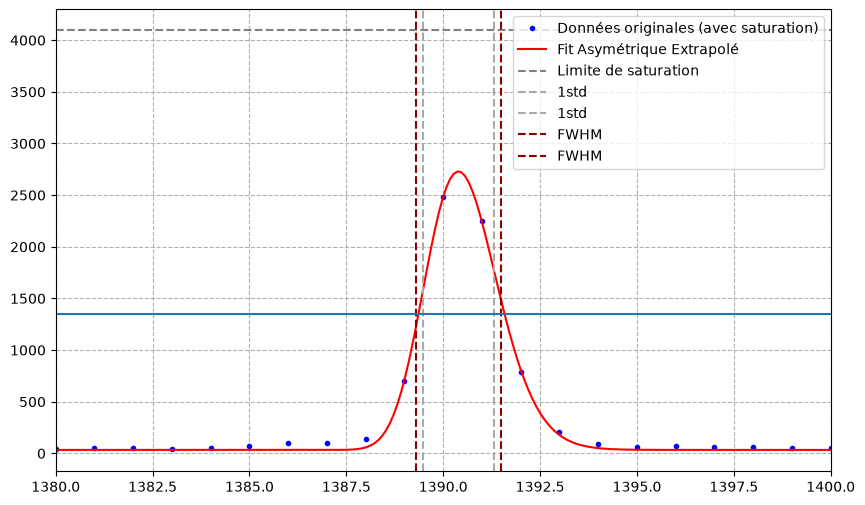

In [ ]:
from scipy.optimize import curve_fit
# 1. Masque pour exclure la saturation
masque = y < 4000
x_fit = x[masque]
y_fit = y[masque]

# 2. Estimations initiales (p0)
A_init = 1000        # Estimé plus haut que la saturation
x0_init = 1391       # Centre du pic
sigma0_init = 2      # Largeur de base
a_init = 0.5         # Init positif pour étaler à droite
y0_init = y0_estime         # Ton fond continu

p0 = [A_init, x0_init, sigma0_init, a_init, y0_init]

# 3. Bornes (bounds) pour éviter que le fit ne donne des valeurs aberrantes
# Format: ([min_A, min_x0, min_sigma0, min_a, min_y0], [max_A, max_x0, max_sigma0, max_a, max_y0])
bounds = ([200, 1385, 0.1, -2, 0], 
          [10000, 1395, 10, 2, 300])

# 4. Calcul du fit
popt, pcov = curve_fit(asymmetric_gaussian, x_fit, y_fit, p0=p0, bounds=bounds)

# Extraction des résultats
A_opt, x0_opt, sigma0_opt, a_opt, y0_opt = popt

print(f"--- Résultats du Fit ---")
print(f"Amplitude réelle estimée : {A_opt:.1f}")
print(f"Centre de la raie (x0)   : {x0_opt:.2f}")
print(f"Fond continu (y0)        : {y0_opt:.1f}")
print(f"Paramètre d'asymétrie (a): {a_opt:.3f}")

# 5. Tracer le résultat pour vérifier
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b.', label='Données originales (avec saturation)')
# plt.plot(x_fit, y_fit, 'g.', label='Données utilisées pour le fit')

# On génère une courbe lisse pour le modèle (qui va extrapoler le sommet caché !)
x_fine = np.linspace(x.min(), x.max(), 20000)
plt.plot(x_fine, asymmetric_gaussian(x_fine, *popt), 'r-', label='Fit Asymétrique Extrapolé')

plt.axhline(4095, color='gray', linestyle='--', label='Limite de saturation')

plt.grid(True, linestyle='--')
plt.xlim(1380,1400)
plt.axvline(x0_opt+sigma0_opt,ls='--', c='darkgrey',label='1std')
plt.axvline(x0_opt-sigma0_opt,ls='--', c='darkgrey',label='1std')
plt.axvline(x0_opt+np.sqrt(2*np.log(2))*sigma0_opt,ls='--', c='darkred',label='FWHM')
plt.axvline(x0_opt-np.sqrt(2*np.log(2))*sigma0_opt,ls='--', c='darkred',label='FWHM')
plt.axhline(A_opt//2)
# plt.ylim(0,1500)
plt.legend()
plt.show()